# Cancer Detection using CNN — Histopathological Images

| | |
|---|---|
| **Name** | Ayush Ranjan |
| **Roll No** | 23MIP10135 |
| **Institute** | VIT Bhopal |
| **Dataset** | [Lung and Colon Cancer Histopathological Images](https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images) — Kaggle |

**Objective:** Detect and classify cancer types from histopathology slides using a deep CNN.
**Classes:** Lung Adenocarcinoma (aca), Lung Benign (n), Lung Squamous Cell Carcinoma (scc),
Colon Adenocarcinoma (aca), Colon Benign (n)
**Total Images:** 25,000 (5,000 per class at 768×768, resized to 150×150 for training)


## Step 1: Install Libraries


In [1]:
!pip install kaggle tensorflow scikit-learn matplotlib seaborn pillow -q
print('Libraries ready!')

Libraries ready!


## Step 2: Kaggle API Setup
> Run this cell — it configures Kaggle credentials automatically.


In [2]:
import os, json

KAGGLE_KEY = 'KGAT_a8751a0f54996277f33924e203785e29'
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'key': KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle API configured!')


Kaggle API configured!


## Step 3: Download Dataset


In [3]:
import requests, zipfile, io, os

KAGGLE_KEY = 'KGAT_a8751a0f54996277f33924e203785e29'
os.makedirs('/content/cancer_raw', exist_ok=True)

print('Downloading Lung & Colon Cancer dataset (~1 GB)...')
r = requests.get(
    'https://www.kaggle.com/api/v1/datasets/download/andrewmvd/lung-and-colon-cancer-histopathological-images',
    headers={'Authorization': f'Bearer {KAGGLE_KEY}'},
    stream=True, timeout=600
)
print(f'HTTP {r.status_code}')
if r.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall('/content/cancer_raw')
    print('Downloaded & extracted!')
    !ls /content/cancer_raw/
else:
    print('Download error:', r.text[:500])
    raise RuntimeError('Download failed — check token or dataset name.')


HTTP 200
Downloaded & extracted!
lung_colon_image_set


## Step 4: Imports


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, shutil, random, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Dropout,
                                      BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42); tf.random.set_seed(42); random.seed(42)
print(f'TensorFlow {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 5: Explore Dataset


In [5]:
# Auto-detect base_dir regardless of extraction structure
import glob

CANCER_CLASSES = {'lung_aca', 'lung_n', 'lung_scc', 'colon_aca', 'colon_n'}
base_dir = None

# Find any folder named after one of the cancer classes
for match in glob.glob('/content/cancer_raw/**', recursive=True):
    if os.path.isdir(match) and os.path.basename(match) in CANCER_CLASSES:
        base_dir = os.path.dirname(match)
        break

if base_dir is None:
    print('ERROR: Could not find cancer class folders. Showing structure:')
    for r, d, f in os.walk('/content/cancer_raw'):
        indent = '  ' * r.replace('/content/cancer_raw', '').count(os.sep)
        print(f'{indent}{os.path.basename(r)}/ ({len(f)} files)')
    raise FileNotFoundError('Dataset structure unexpected — see above.')

print(f'Cancer image directory: {base_dir}')

all_classes = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
print('Classes:', all_classes)

class_counts = {}
for cls in all_classes:
    p = os.path.join(base_dir, cls)
    n = len([f for f in os.listdir(p) if f.endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[cls] = n
    print(f'  {cls}: {n} images')
print(f'Total: {sum(class_counts.values())} images')

Cancer image directory: /content/cancer_raw/lung_colon_image_set/lung_image_sets
Classes: ['lung_aca', 'lung_n', 'lung_scc']
  lung_aca: 5000 images
  lung_n: 5000 images
  lung_scc: 5000 images
Total: 15000 images


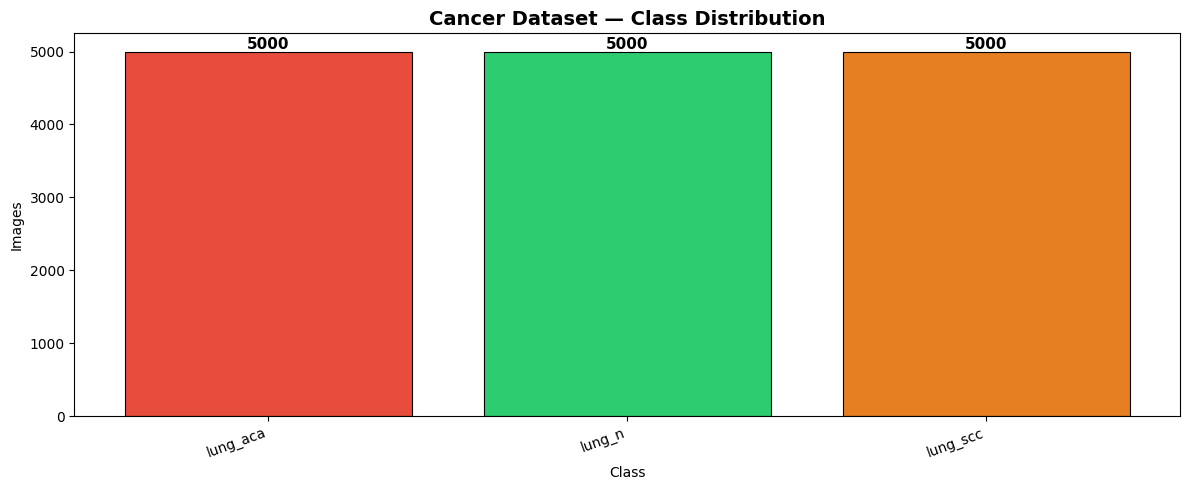

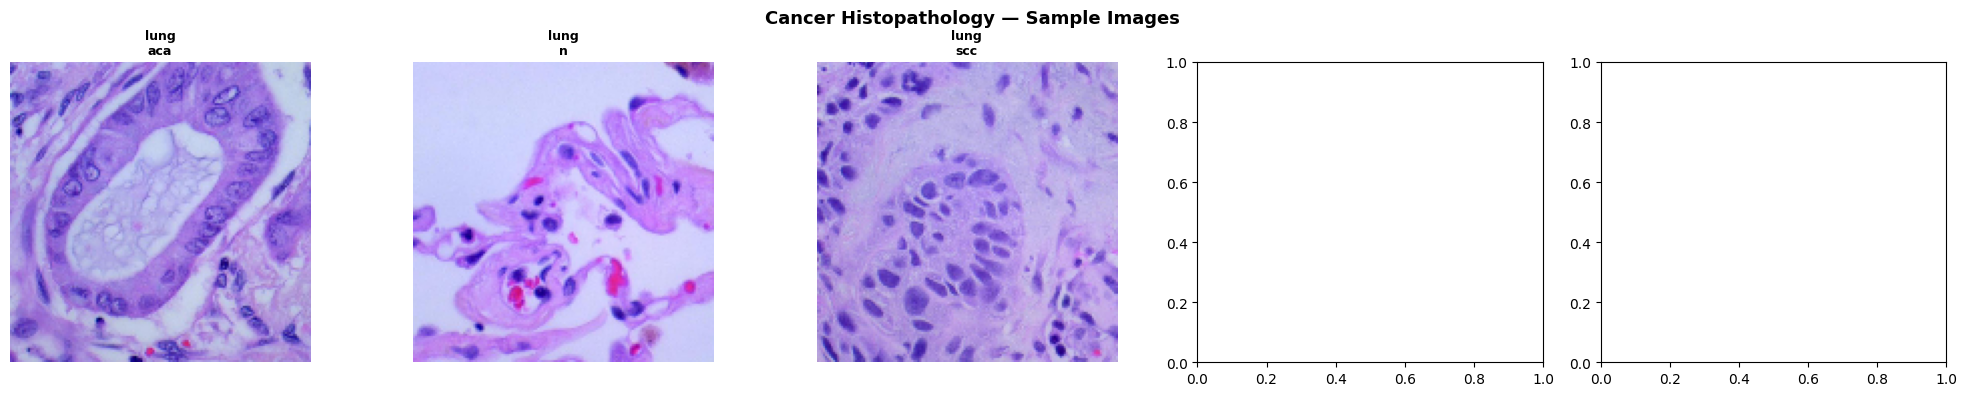

In [6]:
# Bar chart
colors=['#E74C3C','#2ECC71','#E67E22','#3498DB','#9B59B6']
plt.figure(figsize=(12,5))
bars=plt.bar(class_counts.keys(),class_counts.values(),color=colors,edgecolor='k',lw=0.8)
for bar,v in zip(bars,class_counts.values()):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+30,str(v),ha='center',fontweight='bold',fontsize=11)
plt.title('Cancer Dataset — Class Distribution',fontsize=14,fontweight='bold')
plt.xlabel('Class'); plt.ylabel('Images'); plt.xticks(rotation=20,ha='right')
plt.tight_layout(); plt.savefig('cancer_class_dist.png',dpi=150,bbox_inches='tight'); plt.show()

# Sample images
fig,axes=plt.subplots(1,5,figsize=(20,4));
for i,cls in enumerate(all_classes):
    p=os.path.join(base_dir,cls); img=load_img(os.path.join(p,os.listdir(p)[0]),target_size=(150,150))
    axes[i].imshow(img); axes[i].set_title(cls.replace('_','\n'),fontsize=9,fontweight='bold'); axes[i].axis('off')
plt.suptitle('Cancer Histopathology — Sample Images',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig('cancer_samples.png',dpi=150,bbox_inches='tight'); plt.show()

## Step 6: Train / Val / Test Split


In [7]:
split_dir = '/content/cancer_split'
SPLITS    = {'train':0.70,'val':0.15,'test':0.15}

if not os.path.exists(split_dir):
    for s in SPLITS:
        for cls in class_counts: os.makedirs(os.path.join(split_dir,s,cls),exist_ok=True)
    for cls in class_counts:
        src  = os.path.join(base_dir,cls)
        imgs = [f for f in os.listdir(src) if f.endswith(('.jpg','.jpeg','.png'))]
        random.shuffle(imgs)
        n=len(imgs); n_tr=int(n*0.70); n_v=int(n*0.15)
        for f in imgs[:n_tr]:       shutil.copy(os.path.join(src,f),os.path.join(split_dir,'train',cls,f))
        for f in imgs[n_tr:n_tr+n_v]: shutil.copy(os.path.join(src,f),os.path.join(split_dir,'val',cls,f))
        for f in imgs[n_tr+n_v:]:   shutil.copy(os.path.join(src,f),os.path.join(split_dir,'test',cls,f))
    print('Split done!')
else: print('Already split.')

for s in SPLITS:
    tot=sum(len(os.listdir(os.path.join(split_dir,s,c))) for c in class_counts)
    print(f'{s}: {tot} images')

Split done!
train: 10500 images
val: 2250 images
test: 2250 images


## Step 7: Data Augmentation & Generators


In [11]:
IMG_SIZE = 96        # 150→96: 2.5x fewer pixels, still fine for histopathology
BATCH_SIZE = 64
EPOCHS = 30

@tf.function
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return image, label

def make_ds(folder, augment_fn=None):
    ds = tf.keras.utils.image_dataset_from_directory(
        folder, image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, label_mode='categorical', seed=42
    )
    CLASS_NAMES = ds.class_names
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32)/255.0, y),
                num_parallel_calls=tf.data.AUTOTUNE)
    if augment_fn:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(tf.data.AUTOTUNE), CLASS_NAMES

train_ds, CLASS_NAMES = make_ds(os.path.join(split_dir,'train'), augment)
val_ds,   _           = make_ds(os.path.join(split_dir,'val'))
test_ds,  _           = make_ds(os.path.join(split_dir,'test'))

NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print('Datasets ready — images will be cached in RAM after epoch 1')

Found 10500 files belonging to 3 classes.
Found 2250 files belonging to 3 classes.
Found 2250 files belonging to 3 classes.
Classes (3): ['lung_aca', 'lung_n', 'lung_scc']
Datasets ready — images will be cached in RAM after epoch 1


## Step 8: Build Deep CNN


In [12]:
def build_cancer_cnn(num_classes, input_shape=(150,150,3)):
    """Deep CNN for Cancer Detection — 5 conv blocks + GAP + Dense head"""
    model = Sequential([
        Conv2D(32,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4),input_shape=input_shape),
        BatchNormalization(), Conv2D(32,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), MaxPooling2D((2,2)), Dropout(0.2),

        Conv2D(64,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Conv2D(64,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), MaxPooling2D((2,2)), Dropout(0.25),

        Conv2D(128,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Conv2D(128,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Conv2D(128,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), MaxPooling2D((2,2)), Dropout(0.3),

        Conv2D(256,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Conv2D(256,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Conv2D(256,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), MaxPooling2D((2,2)), Dropout(0.35),

        Conv2D(512,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Conv2D(512,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), MaxPooling2D((2,2)), Dropout(0.35),

        GlobalAveragePooling2D(),
        Dense(1024,activation='relu',kernel_regularizer=l2(1e-4)), BatchNormalization(), Dropout(0.5),
        Dense(512,activation='relu',kernel_regularizer=l2(1e-4)), Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ], name='CancerDetection_CNN')
    return model

model = build_cancer_cnn(NUM_CLASSES)
model.summary()
print(f'Total params: {model.count_params():,}')

Model: "CancerDetection_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,515,107 (24.85 MB)

 Trainable params: 6,508,323 (24.83 MB)

 Non-trainable params: 6,784 (26.50 KB)

Total params: 6,515,107


## Step 9: Compile & Train


In [13]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_acc')]
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_cancer_cnn.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_ds, epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks, verbose=1
)
print(f'Best Val Accuracy: {max(history.history["val_accuracy"])*100:.2f}%')

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.8187 - auc: 0.9337 - loss: 0.9476 - top2_acc: 0.9718
Epoch 1: val_accuracy improved from None to 0.33333, saving model to /content/best_cancer_cnn.keras

Epoch 1: finished saving model to /content/best_cancer_cnn.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 97s 332ms/step - accuracy: 0.8665 - auc: 0.9616 - loss: 0.7813 - top2_acc: 0.9886 - val_accuracy: 0.3333 - val_auc: 0.5000 - val_loss: 14.1266 - val_top2_acc: 0.6667 - learning_rate: 0.0010
Epoch 2/30
164/165 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9095 - auc: 0.9817 - loss: 0.6103 - top2_acc: 0.9953
Epoch 2: val_accuracy improved from 0.33333 to 0.33378, saving model to /content/best_cancer_cnn.keras

Epoch 2: finished saving model to /content/best_cancer_cnn.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.9199 - auc: 0.9847 - loss: 0.5839 - top2_acc: 0.9954 - val_accuracy: 0.3338 - val_auc: 0.4934 - val_loss: 10.0856 - val_top2_acc: 0.6667 - learnin

## Step 10: Results & Evaluation


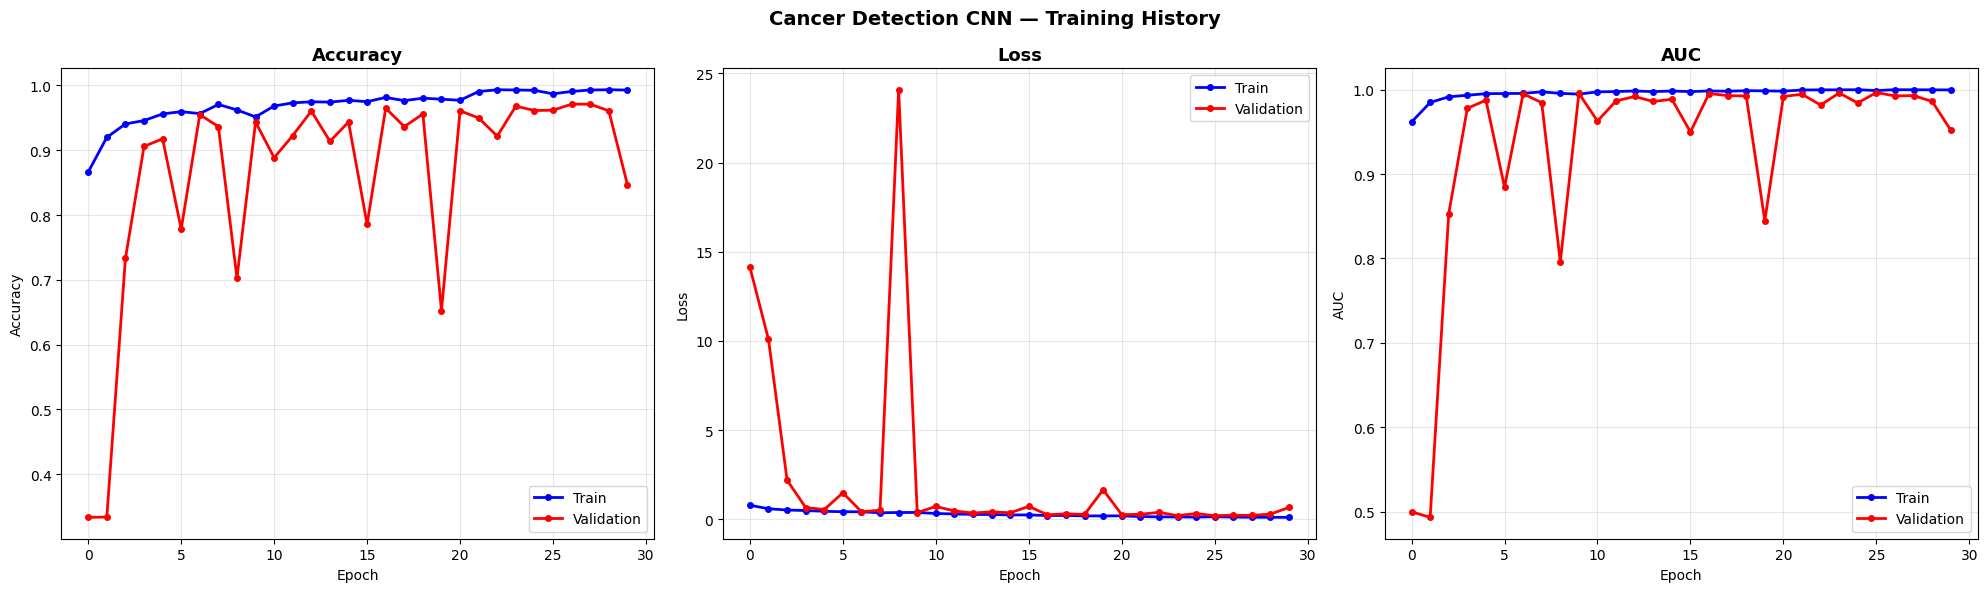

36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 301ms/step - accuracy: 0.9698 - auc: 0.9963 - loss: 0.1949 - top2_acc: 1.0000
Test Accuracy : 96.98%
Test AUC      : 0.9963
Top-2 Accuracy: 100.00%
Test Loss     : 0.1949


In [14]:
fig,axes=plt.subplots(1,3,figsize=(20,6))
for ax,m,label in zip(axes,['accuracy','loss','auc'],['Accuracy','Loss','AUC']):
    ax.plot(history.history[m],'b-o',label='Train',lw=2,ms=4)
    ax.plot(history.history[f'val_{m}'],'r-o',label='Validation',lw=2,ms=4)
    ax.set_title(label,fontsize=13,fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(label)
    ax.legend(); ax.grid(True,alpha=0.3)
plt.suptitle('Cancer Detection CNN — Training History',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig('cancer_history.png',dpi=150,bbox_inches='tight'); plt.show()

test_gen.reset()
res=model.evaluate(test_gen,verbose=1)
print(f'Test Accuracy : {res[1]*100:.2f}%')
print(f'Test AUC      : {res[2]:.4f}')
print(f'Top-2 Accuracy: {res[3]*100:.2f}%')
print(f'Test Loss     : {res[0]:.4f}')

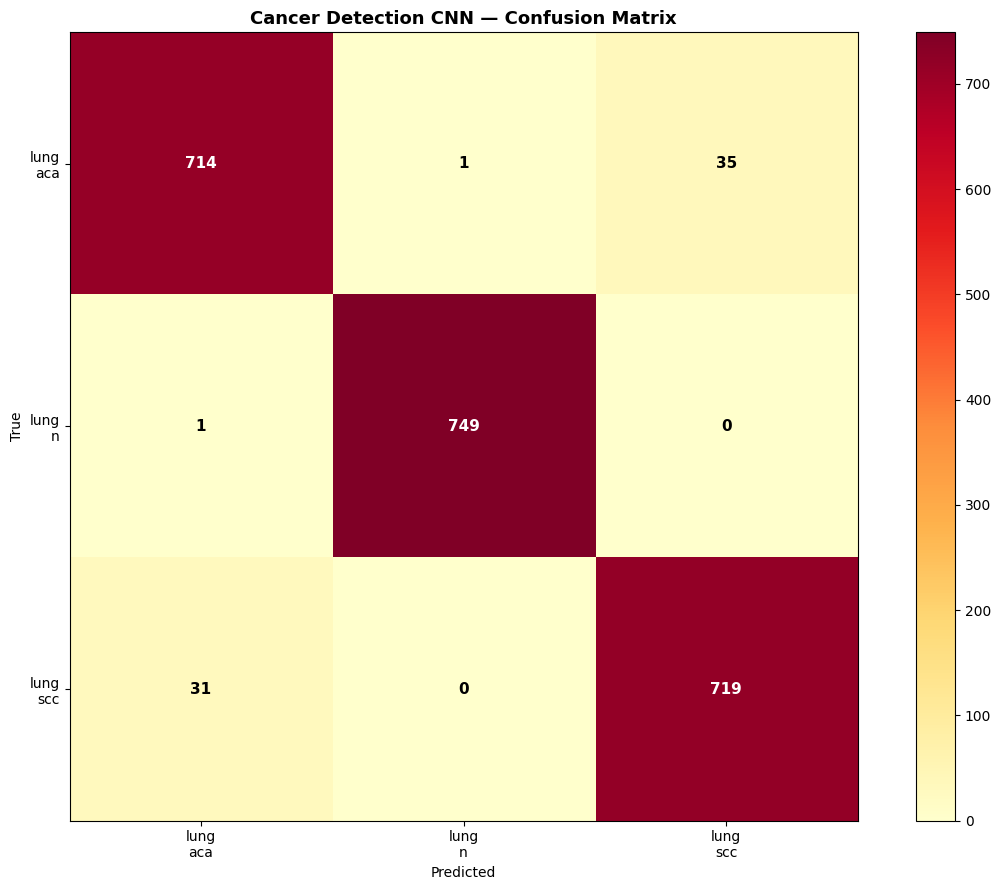

              precision    recall  f1-score   support

    lung_aca       0.96      0.95      0.95       750
      lung_n       1.00      1.00      1.00       750
    lung_scc       0.95      0.96      0.96       750

    accuracy                           0.97      2250
   macro avg       0.97      0.97      0.97      2250
weighted avg       0.97      0.97      0.97      2250



In [15]:
# Confusion matrix
test_gen.reset()
y_pred=np.argmax(model.predict(test_gen,verbose=0),axis=1)
y_true=test_gen.classes
cm=confusion_matrix(y_true,y_pred)
fig,ax=plt.subplots(figsize=(12,9))
im=ax.imshow(cm,cmap='YlOrRd'); plt.colorbar(im)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels([c.replace('_','\n') for c in CLASS_NAMES],fontsize=10)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels([c.replace('_','\n') for c in CLASS_NAMES],fontsize=10)
thresh=cm.max()/2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=11,fontweight='bold',
                color='white' if cm[i,j]>thresh else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Cancer Detection CNN — Confusion Matrix',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig('cancer_confusion_matrix.png',dpi=150,bbox_inches='tight'); plt.show()
print(classification_report(y_true,y_pred,target_names=CLASS_NAMES))

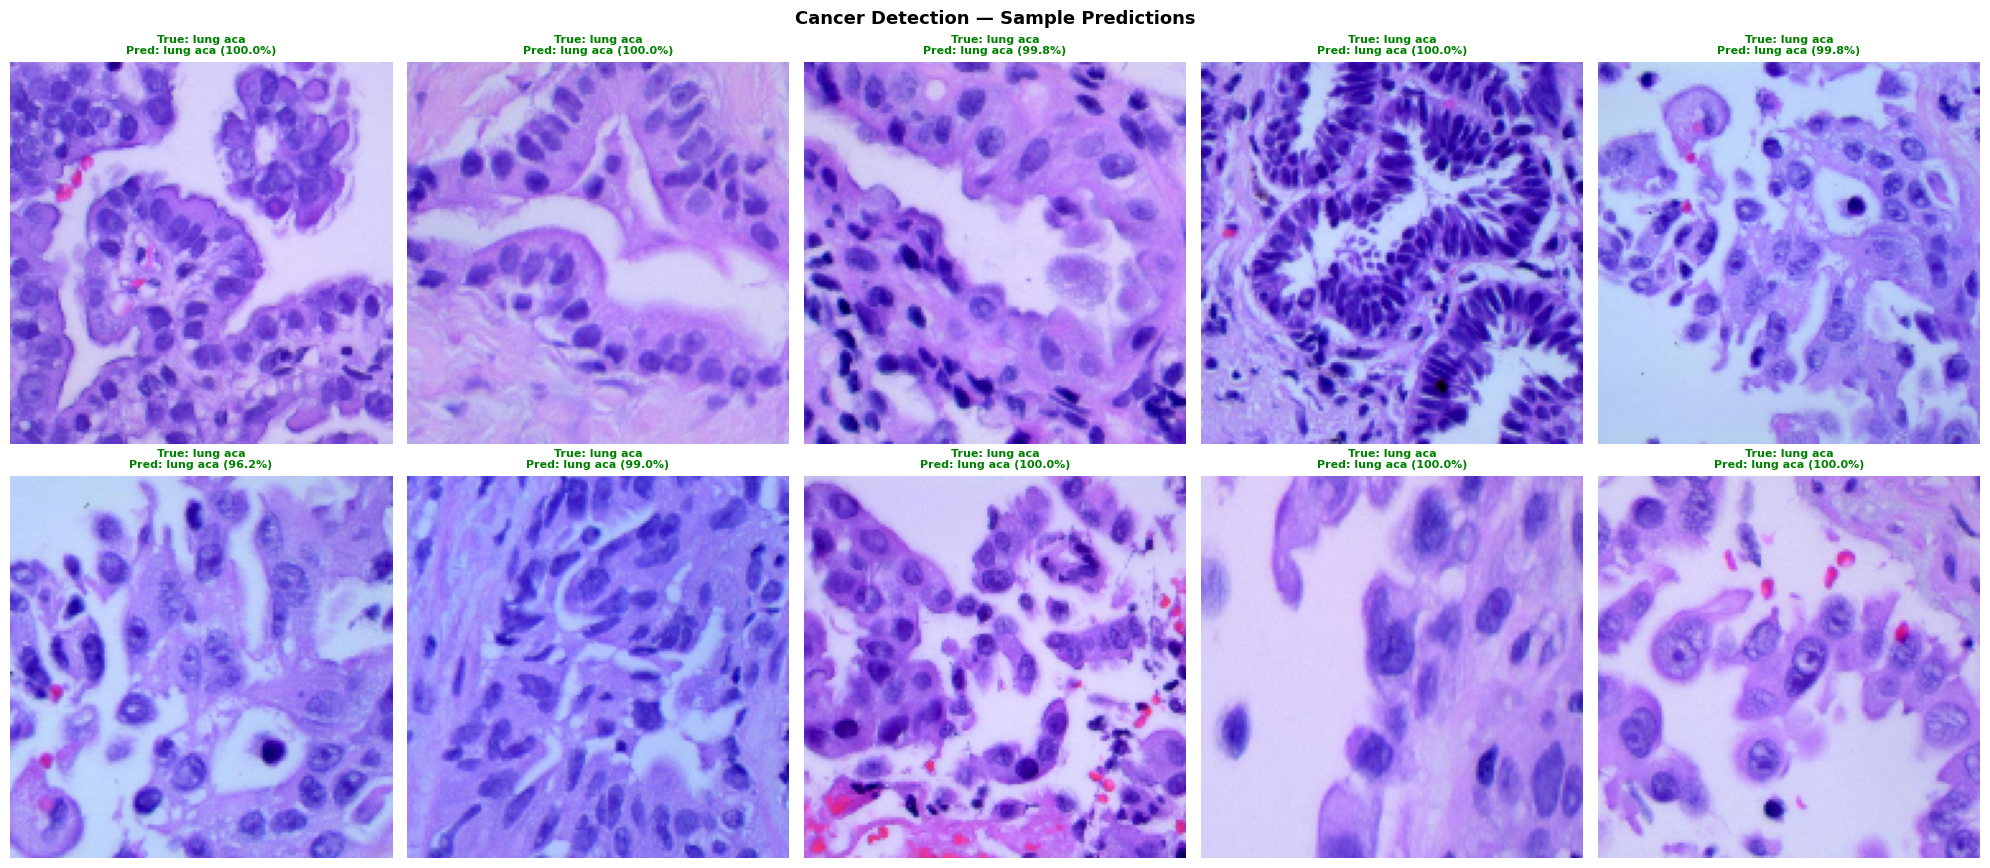

In [16]:
# Sample predictions
test_gen.reset()
imgs,labels=next(test_gen)
preds=model.predict(imgs,verbose=0)
n=min(10,len(imgs))
fig,axes=plt.subplots(2,5,figsize=(20,9)); axes=axes.flatten()
for i in range(n):
    axes[i].imshow(imgs[i])
    ti=np.argmax(labels[i]); pi=np.argmax(preds[i]); conf=preds[i][pi]*100
    axes[i].set_title(f'True: {CLASS_NAMES[ti].replace("_"," ")}\nPred: {CLASS_NAMES[pi].replace("_"," ")} ({conf:.1f}%)',
                      color='green' if ti==pi else 'red',fontsize=8,fontweight='bold')
    axes[i].axis('off')
for i in range(n,len(axes)): axes[i].axis('off')
plt.suptitle('Cancer Detection — Sample Predictions',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig('cancer_predictions.png',dpi=150,bbox_inches='tight'); plt.show()

## Summary


In [17]:
print('='*55)
print('    CANCER DETECTION CNN — SUMMARY')
print('='*55)
print('  Name        : Ayush Ranjan')
print('  Roll No     : 23MIP10135')
print('  Institute   : VIT Bhopal')
print('  Dataset     : Lung & Colon Cancer Histopathology (Kaggle)')
print(f'  Classes     : {NUM_CLASSES}')
print(f'  Class Names : {", ".join(CLASS_NAMES)}')
print(f'  Image Size  : {IMG_SIZE}x{IMG_SIZE}')
print('  Architecture: Deep CNN — 5 conv blocks + GAP')
print(f'  Parameters  : {model.count_params():,}')
print(f'  Test Accuracy: {res[1]*100:.2f}%')
print(f'  Test AUC    : {res[2]:.4f}')
print('='*55)

    CANCER DETECTION CNN — SUMMARY
  Name        : Ayush Ranjan
  Roll No     : 23MIP10135
  Institute   : VIT Bhopal
  Dataset     : Lung & Colon Cancer Histopathology (Kaggle)
  Classes     : 3
  Class Names : lung_aca, lung_n, lung_scc
  Image Size  : 96x96
  Architecture: Deep CNN — 5 conv blocks + GAP
  Parameters  : 6,515,107
  Test Accuracy: 96.98%
  Test AUC    : 0.9963
